In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
!pip install torchaudio librosa numpy soundfile matplotlib tqdm torchcrepe torch


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torchaudio
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import scipy.signal
import torchcrepe
from PIL import Image
from torchvision import transforms

from glob import glob
from tqdm import tqdm
from random import choice
from pathlib import Path

from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.notebook import tqdm
from torch.cuda.amp import autocast, GradScaler





In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("[INFO] GPU is available:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("[INFO] GPU not available — using CPU.")

[INFO] GPU not available — using CPU.


In [ ]:
DATASET_PATH = Path("./train-clean-100")  # Update path as needed

if not DATASET_PATH.exists():
    print(f"[ERROR] Dataset path does not exist: {DATASET_PATH}")
    print("Please verify you extracted the dataset correctly to this path.")
    sys.exit(1)
else:
    print(f"[INFO] Dataset found at: {DATASET_PATH}")



[INFO] Dataset found at: train-clean-100


In [ ]:
# Mel-spectrogram extractor
SAMPLE_RATE = 16000
N_MELS = 80

mel_extractor = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=1024,
    hop_length=256,
    n_mels=N_MELS,
    win_length=1024,
    window_fn=torch.hann_window
).to(device)

In [ ]:
def extract_f0(waveform, sr=SAMPLE_RATE):
    # waveform: Tensor of shape (T,)
    waveform = waveform.unsqueeze(0)  # shape (1, T)
    f0, periodicity = torchcrepe.predict(
        waveform,
        sr,
        hop_length=160,  # for 10ms hop
        fmin=50,
        fmax=500,
        model='full',
        batch_size=512,
        device=waveform.device,
        return_periodicity=True
    )
    return f0.squeeze(0)


In [ ]:
# Parse transcripts and audio files with conversion logging

def load_transcripts(audio_dir):
    trans_dict = {}
    for txt_file in audio_dir.rglob("*.trans.txt"):
        with open(txt_file, 'r') as f:
            for line in f:
                parts = line.strip().split(" ", 1)
                if len(parts) == 2:
                    utt_id, text = parts
                    trans_dict[utt_id] = text
    return trans_dict

def load_audio(file_path):

    print(f"[DEBUG] Processing file: {file_path.relative_to(DATASET_PATH.parent)}")
    waveform, sr = torchaudio.load(file_path)
    if sr != SAMPLE_RATE:
        resampler = Resample(orig_freq=sr, new_freq=SAMPLE_RATE)
        waveform = resampler(waveform)
    return waveform.squeeze(0)

transcripts = load_transcripts(DATASET_PATH)
print(f"Loaded transcripts: {len(transcripts)}")


Loaded transcripts: 28539


In [ ]:
# Simulate whispered audio using pitch suppression
def simulate_whisper(waveform, sr=SAMPLE_RATE):
    # Remove pitch by applying high-pass filter (mock whisper)
    sos = scipy.signal.butter(10, 150, 'hp', fs=sr, output='sos')
    filtered = scipy.signal.sosfilt(sos, waveform.numpy())
    return torch.from_numpy(filtered).float()

# Debug test

test_file = list(DATASET_PATH.rglob("*.flac"))[0]
wav = load_audio(test_file)
whisper_wav = simulate_whisper(wav)
sf.write("debug_voiced.wav", wav.numpy(), SAMPLE_RATE)
sf.write("debug_whisper.wav", whisper_wav.numpy(), SAMPLE_RATE)
print(f"Saved debug_voiced.wav and debug_whisper.wav")


[DEBUG] Processing file: train-clean-100\103\1240\103-1240-0000.flac
Saved debug_voiced.wav and debug_whisper.wav


In [ ]:
WHISPER_IMG_DIR = Path("./mel_images/whisper")
VOICED_IMG_DIR = Path("./mel_images/voiced")
F0_DIR = Path("./f0_values")

In [ ]:
to_tensor = transforms.ToTensor()

In [ ]:
os.makedirs(WHISPER_IMG_DIR, exist_ok=True)
os.makedirs(VOICED_IMG_DIR, exist_ok=True)
os.makedirs(F0_DIR, exist_ok=True)

In [ ]:
def save_mel_as_image(mel_tensor, save_path):
    mel_np = mel_tensor.numpy()
    mel_min, mel_max = mel_np.min(), mel_np.max()
    mel_img = 255 * (mel_np - mel_min) / (mel_max - mel_min + 1e-8)
    mel_img = mel_img.astype(np.uint8)
    img = Image.fromarray(mel_img)
    img.save(save_path)

In [ ]:
# Extract mel-spectrograms from voiced and whisper
def extract_mel(waveform):
    return mel_extractor(waveform).clamp(min=1e-5).log()

# -------- MAIN PROCESSING FUNCTION ----------
def process_sample(file_path):
    utt_id = Path(file_path).stem
    wav = load_audio(file_path)
    whisper_wav = simulate_whisper(wav)

    # Move to GPU if available
    if isinstance(wav, torch.Tensor):
        wav = wav.to(device)
        whisper_wav = whisper_wav.to(device)

    mel_voiced = extract_mel(wav)
    mel_whisper = extract_mel(whisper_wav)
    f0 = extract_f0(wav)

    return utt_id, mel_whisper.cpu(), mel_voiced.cpu(), f0.cpu(), transcripts.get(utt_id, "")


In [ ]:
train_files = list(DATASET_PATH.rglob("*.flac"))

In [ ]:

# processed_count = 0

# with tqdm(train_files, desc="Processing", dynamic_ncols=True) as progress_bar:
#     for fpath in progress_bar:
#         utt_id, mel_whisper, mel_voiced, f0, text = process_sample(fpath)

#         # Save whisper and voiced mels as PNG
#         save_mel_as_image(mel_whisper, WHISPER_IMG_DIR / f"{utt_id}.png")
#         save_mel_as_image(mel_voiced, VOICED_IMG_DIR / f"{utt_id}.png")

#         # Save F0 as numpy
#         np.save(F0_DIR / f"{utt_id}.npy", f0.numpy())

#         processed_count += 1
#         progress_bar.set_description(f"utt: {utt_id}")


In [ ]:

processed_count = 0

for fpath in tqdm(train_files, desc="Processing", dynamic_ncols=True):
    utt_id = Path(fpath).stem

    whisper_img_path = WHISPER_IMG_DIR / f"{utt_id}.png"
    voiced_img_path = VOICED_IMG_DIR / f"{utt_id}.png"
    f0_npy_path = F0_DIR / f"{utt_id}.npy"

    # Skip if all outputs already exist
    if whisper_img_path.exists() and voiced_img_path.exists() and f0_npy_path.exists():
        print(f"Already found: {whisper_img_path}, {voiced_img_path}, {f0_npy_path}")
        continue

    utt_id, mel_whisper, mel_voiced, f0, text = process_sample(fpath)

    save_mel_as_image(mel_whisper, whisper_img_path)
    save_mel_as_image(mel_voiced, voiced_img_path)
    np.save(f0_npy_path, f0.numpy())

    processed_count += 1


Processing:   0%|          | 0/28539 [00:00<?, ?it/s]

Already found: mel_images\whisper\103-1240-0000.png, mel_images\voiced\103-1240-0000.png, f0_values\103-1240-0000.npy
Already found: mel_images\whisper\103-1240-0001.png, mel_images\voiced\103-1240-0001.png, f0_values\103-1240-0001.npy
Already found: mel_images\whisper\103-1240-0002.png, mel_images\voiced\103-1240-0002.png, f0_values\103-1240-0002.npy
Already found: mel_images\whisper\103-1240-0003.png, mel_images\voiced\103-1240-0003.png, f0_values\103-1240-0003.npy
Already found: mel_images\whisper\103-1240-0004.png, mel_images\voiced\103-1240-0004.png, f0_values\103-1240-0004.npy
Already found: mel_images\whisper\103-1240-0005.png, mel_images\voiced\103-1240-0005.png, f0_values\103-1240-0005.npy
Already found: mel_images\whisper\103-1240-0006.png, mel_images\voiced\103-1240-0006.png, f0_values\103-1240-0006.npy
Already found: mel_images\whisper\103-1240-0007.png, mel_images\voiced\103-1240-0007.png, f0_values\103-1240-0007.npy
Already found: mel_images\whisper\103-1240-0008.png, mel

In [ ]:
# Summary
print("\nMel-spectrogram image extraction complete.")
print(f"Total files processed: {processed_count}")
print(f"Whisper mel images saved: {len(list(WHISPER_IMG_DIR.glob('*.png')))}")
print(f"Voiced mel images saved: {len(list(VOICED_IMG_DIR.glob('*.png')))}")
print(f"F0 values saved: {len(list(F0_DIR.glob('*.npy')))}")


Mel-spectrogram image extraction complete.
Total files processed: 0
Whisper mel images saved: 28539
Voiced mel images saved: 28539
F0 values saved: 28539


Sample ID: 1963-142393-0028


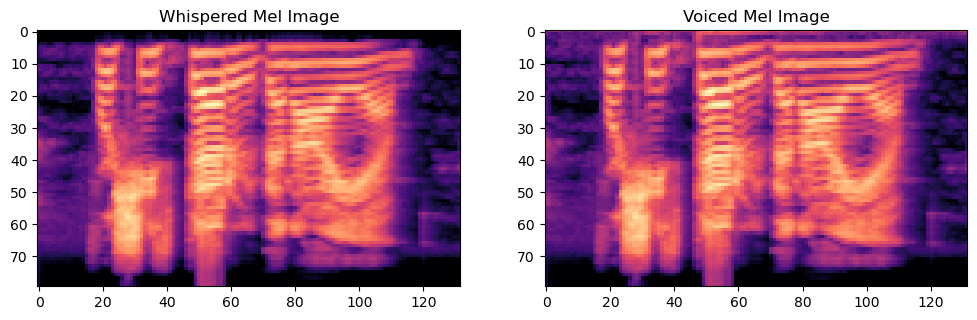

In [ ]:
# Preview
from IPython.display import display

sample = choice(list(WHISPER_IMG_DIR.glob("*.png"))).stem
whisper_img = Image.open(WHISPER_IMG_DIR / f"{sample}.png")
voiced_img = Image.open(VOICED_IMG_DIR / f"{sample}.png")

print(f"Sample ID: {sample}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title("Whispered Mel Image")
plt.imshow(whisper_img, cmap='magma')
plt.subplot(1, 2, 2)
plt.title("Voiced Mel Image")
plt.imshow(voiced_img, cmap='magma')
plt.show()


In [ ]:
print("Whisper image dir:", WHISPER_IMG_DIR)
print("Voiced image dir:", VOICED_IMG_DIR)
print("F0 dir:", F0_DIR)

# Check how many files are found
print("Whisper images:", len(list(WHISPER_IMG_DIR.glob('*.png'))))
print("Voiced images:", len(list(VOICED_IMG_DIR.glob('*.png'))))
print("F0 files:", len(list(F0_DIR.glob('*.npy'))))


Whisper image dir: mel_images\whisper
Voiced image dir: mel_images\voiced
F0 dir: f0_values
Whisper images: 28539
Voiced images: 28539
F0 files: 28539


In [ ]:
# Transducer components (Encoder + Predictor + Joint)

class Encoder(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        x, _ = self.lstm(x)
        return self.linear(x)

class Predictor(nn.Module):
    def __init__(self, output_dim=80, hidden_dim=256):
        super().__init__()
        self.rnn = nn.LSTM(output_dim, hidden_dim, batch_first=True)

    def forward(self, y):
        y, _ = self.rnn(y)
        return y

class JointNet(nn.Module):
    def __init__(self, hidden_dim=256, output_dim=80):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, enc_out, pred_out):
        joint = torch.cat((enc_out, pred_out), dim=-1)
        return self.fc(joint)

class Transducer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.predictor = Predictor()
        self.joint = JointNet()
        self.f0_head = nn.Linear(256, 1)  # Predict 1D F0 from encoded output

    def forward(self, x, y):
        enc_out = self.encoder(x)
        pred_out = self.predictor(y)
        mel_out = self.joint(enc_out, pred_out)
        f0_out = self.f0_head(enc_out).squeeze(-1)  # shape: (B, T)
        return mel_out, f0_out



In [ ]:
# Whisper→Voiced Mel dataset loader
class WhisperToVoicedImageDataset(torch.utils.data.Dataset):
    def __init__(self, whisper_dir, voiced_dir, f0_dir):
        self.whisper_files = list(whisper_dir.glob("*.png"))
        self.voiced_dir = voiced_dir
        self.f0_dir = f0_dir

    def __len__(self):
        return len(self.whisper_files)

    def __getitem__(self, idx):
        whisper_path = self.whisper_files[idx]
        utt_id = whisper_path.stem

        # Load mel images and convert to tensor (C, H, W) → (H, W)
        mel_whisper = to_tensor(Image.open(whisper_path)).squeeze(0).T  # (T, 80)
        mel_voiced = to_tensor(Image.open(self.voiced_dir / f"{utt_id}.png")).squeeze(0).T

        # Load F0 (T,)
        f0 = torch.from_numpy(np.load(self.f0_dir / f"{utt_id}.npy")).float()

        return mel_whisper, mel_voiced, f0


def collate_fn(batch):
    x_batch, y_batch, f0_batch = zip(*batch)
    x_batch = nn.utils.rnn.pad_sequence(x_batch, batch_first=True)
    y_batch = nn.utils.rnn.pad_sequence(y_batch, batch_first=True)
    f0_batch = nn.utils.rnn.pad_sequence(f0_batch, batch_first=True)
    return x_batch, y_batch, f0_batch


train_dataset = WhisperToVoicedImageDataset(WHISPER_IMG_DIR, VOICED_IMG_DIR, F0_DIR)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)





In [ ]:
os.makedirs("Model", exist_ok=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Transducer().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion_mel = nn.MSELoss(reduction='mean')
scaler = GradScaler()
# 120
EPOCHS = 80
loss_history = []
best_loss = float('inf')
os.makedirs("./Model", exist_ok=True)
best_model_path = "./Model/transducer_best.pt"

print(f"[INFO] Training on device: {device}")

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", dynamic_ncols=True, leave=False)
    for x_batch, y_batch, f0_batch in loop:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        f0_batch = f0_batch.to(device)

        optimizer.zero_grad()

        with autocast():
            mel_pred, f0_pred = model(x_batch, y_batch)

            min_len = min(f0_pred.shape[1], f0_batch.shape[1])
            f0_pred = f0_pred[:, :min_len]
            f0_batch = f0_batch[:, :min_len]

            voiced_mask = (f0_batch > 0).float()
            f0_batch_clamped = torch.clamp(f0_batch, min=1e-5)
            log_f0_gt = torch.log(f0_batch_clamped)
            log_f0_pred = torch.log(torch.clamp(f0_pred, min=1e-5))

            loss_f0 = (((log_f0_pred - log_f0_gt) ** 2) * voiced_mask).sum()
            loss_f0 = torch.sqrt(loss_f0 / (voiced_mask.sum() + 1e-5))

            loss_mel = criterion_mel(mel_pred, y_batch)

            loss = loss_mel + 0.5 * loss_f0

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())
    loop.close()
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"\n[Epoch {epoch+1}] Avg Loss: {avg_loss:.4f}")

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved at epoch {epoch+1} with loss {best_loss:.4f}")

# Save final model
final_model_path = "./Model/transducer_final.pt"
torch.save(model.state_dict(), final_model_path)
print(f"\nFinal model saved to: {final_model_path}")


[INFO] Training on device: cuda


C:\Users\Admin\AppData\Local\Temp\ipykernel_16836\2082338613.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1/80:   0%|          | 0/892 [00:00<?, ?it/s]

C:\Users\Admin\AppData\Local\Temp\ipykernel_16836\2082338613.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



[Epoch 1] Avg Loss: 0.2751
Best model saved at epoch 1 with loss 0.2751


...


[Epoch 78] Avg Loss: 0.0856


Epoch 79/80:   0%|          | 0/892 [00:00<?, ?it/s]


[Epoch 79] Avg Loss: 0.0861


Epoch 80/80:   0%|          | 0/892 [00:00<?, ?it/s]


[Epoch 80] Avg Loss: 0.0846
Best model saved at epoch 80 with loss 0.0846

Final model saved to: ./Model/transducer_final.pt


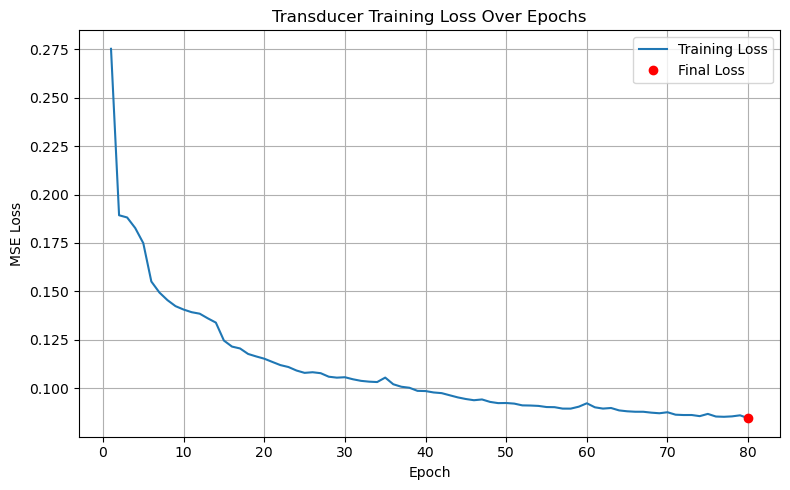

In [ ]:
# Loss plot with extra debug info
plt.figure(figsize=(8, 5))
epochs = range(1, len(loss_history) + 1)
plt.plot(epochs, loss_history, label="Training Loss")
plt.plot(len(loss_history), loss_history[-1], 'ro', label="Final Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transducer Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("training_loss_plot.png")
plt.show()


In [ ]:
# Print loss summary
print("Training Summary:")
print(f"Total Epochs: {len(loss_history)}")
print(f"Final Epoch Loss (MSE): {loss_history[-1]:.4f}")
print(f"Best Loss: {min(loss_history):.4f} at Epoch {loss_history.index(min(loss_history)) + 1}")


Training Summary:
Total Epochs: 80
Final Epoch Loss (MSE): 0.0846
Best Loss: 0.0846 at Epoch 80


In [ ]:
# RMSE: Interpretable form of error
final_rmse = loss_history[-1] ** 0.5
print(f"Final RMSE (Root Mean Square Error): {final_rmse:.4f}")

Final RMSE (Root Mean Square Error): 0.2909


In [ ]:
#Validation
model = Transducer().to(device)  # or your F0 model
model.load_state_dict(torch.load("Model/transducer_best.pt"))
model.eval()


Transducer(
  (encoder): Encoder(
    (lstm): LSTM(80, 256, batch_first=True, bidirectional=True)
    (linear): Linear(in_features=512, out_features=256, bias=True)
  )
  (predictor): Predictor(
    (rnn): LSTM(80, 256, batch_first=True)
  )
  (joint): JointNet(
    (fc): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=80, bias=True)
    )
  )
  (f0_head): Linear(in_features=256, out_features=1, bias=True)
)

# F0


In [ ]:
# transformer_f0_estimator
class TransformerF0Estimator(nn.Module):
    def __init__(self, input_dim=80, d_model=256, nhead=4, num_layers=4):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,batch_first=True,)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, 1)  # 1D F0 output

    def forward(self, mel):
        """
        mel: (B, T, 80)
        """
        x = self.input_proj(mel)  # (B, T, d_model)
        x = x.permute(1, 0, 2)    # (T, B, d_model)
        x = self.transformer(x)   # (T, B, d_model)
        x = x.permute(1, 0, 2)    # (B, T, d_model)
        f0_pred = self.output_proj(x).squeeze(-1)  # (B, T)
        return f0_pred


In [ ]:
model = TransformerF0Estimator().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [ ]:

loss_history = []
best_loss = float("inf")
#50
EPOCHS = 30

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    # Set up a nicely styled TQDM progress bar for the epoch
    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        dynamic_ncols=True,
        leave=True,  # set to True so it prints the final line
        bar_format="{l_bar}{bar:30}{r_bar}",
        colour="cyan"  # optional: use any color supported
    )

    for whisper_mel, mel_output, gt_f0 in progress_bar:
        whisper_mel = whisper_mel.to(device)
        gt_f0 = gt_f0.to(device)

        # Voiced mask
        voiced_mask = (gt_f0 > 0).float()

        # Log-F0 transform
        gt_f0 = torch.clamp(gt_f0, min=1e-5)
        log_gt_f0 = torch.log(gt_f0)

        # Forward pass
        optimizer.zero_grad()
        pred_log_f0 = model(whisper_mel)

        # Align and compute loss
        min_len = min(pred_log_f0.shape[1], log_gt_f0.shape[1])
        pred_log_f0 = pred_log_f0[:, :min_len]
        log_gt_f0 = log_gt_f0[:, :min_len]
        mask = voiced_mask[:, :min_len]

        squared_error = (pred_log_f0 - log_gt_f0) ** 2
        masked_se = squared_error * mask
        loss = torch.sqrt(masked_se.sum() / mask.sum().clamp(min=1.0))

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Update progress bar with batch loss
        progress_bar.set_postfix(batch_loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Update progress bar description after loop (optional)
    print(f"Epoch {epoch+1}/{EPOCHS} - Avg Loss: {avg_loss:.4f}")

    # Save best checkpoint
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "./Model/F0_transformer_best.pt")
        print("Best model checkpoint saved.")


Epoch 1/30:   0%|                              | 0/892 [00:00<?, ?it/s]

Epoch 1/30 - Avg Loss: 0.3944
Best model checkpoint saved.


Epoch 2/30:   0%|                              | 0/892 [00:00<?, ?it/s]

Epoch 2/30 - Avg Loss: 0.3648
Best model checkpoint saved.


Epoch 3/30:   0%|                              | 0/892 [00:00<?, ?it/s]

...

Epoch 28/30 - Avg Loss: 0.2946
Best model checkpoint saved.


Epoch 29/30:   0%|                              | 0/892 [00:00<?, ?it/s]

Epoch 29/30 - Avg Loss: 0.2947


Epoch 30/30:   0%|                              | 0/892 [00:00<?, ?it/s]

Epoch 30/30 - Avg Loss: 0.2941
Best model checkpoint saved.


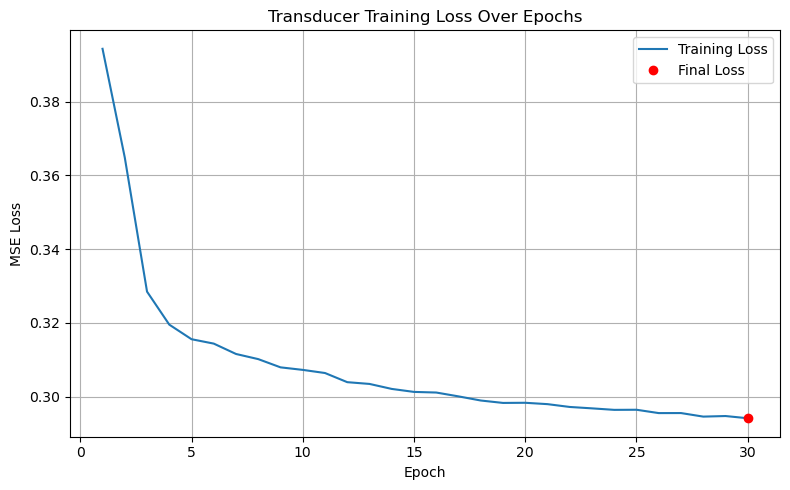

In [ ]:

plt.figure(figsize=(8, 5))
epochs = range(1, len(loss_history) + 1)
plt.plot(epochs, loss_history, label="Training Loss")
plt.plot(len(loss_history), loss_history[-1], 'ro', label="Final Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Transducer Training Loss Over Epochs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("training_loss_plot.png")
plt.show()


In [ ]:
# Print loss summary
print("Training Summary:")
print(f"Total Epochs: {len(loss_history)}")
print(f"Final Epoch Loss (MSE): {loss_history[-1]:.4f}")
print(f"Best Loss: {min(loss_history):.4f} at Epoch {loss_history.index(min(loss_history)) + 1}")



Training Summary:
Total Epochs: 30
Final Epoch Loss (MSE): 0.2941
Best Loss: 0.2941 at Epoch 30


In [ ]:
# RMSE: Interpretable form of error
final_rmse = loss_history[-1] ** 0.5
print(f"Final RMSE (Root Mean Square Error): {final_rmse:.4f}")

Final RMSE (Root Mean Square Error): 0.5423


# GAN

In [16]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [17]:

ROOT_DIR = Path(r"Z:/")  # <-- Update if needed
VOICED_DIR = ROOT_DIR / "mel_images" / "voiced"
WHISPER_DIR = ROOT_DIR / "mel_images" / "whisper"
PSEUDO_DIR = ROOT_DIR / "mel_images" / "pseudo_whisper"


In [18]:

os.makedirs(PSEUDO_DIR, exist_ok=True)

In [19]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Device:", device)
if device.type == 'cuda':
    print("[INFO] CUDA available:", torch.cuda.is_available())
    print("[INFO] Current device:", torch.cuda.current_device())
    print("[INFO] Device name:", torch.cuda.get_device_name(torch.cuda.current_device()))


[INFO] Device: cuda
[INFO] CUDA available: True
[INFO] Current device: 0
[INFO] Device name: NVIDIA GeForce RTX 3050


In [20]:
# Hyperparams for pseudo generation
FREQ_CUTOFF_RATIO = 0.25
NOISE_STD = 0.02
RESCALE = True

In [21]:
# -----------------------------
# Load/save mel images
# -----------------------------
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

def load_mel_image(path):
    img = Image.open(path).convert("L")
    arr = np.asarray(img).astype(np.float32) / 255.0
    return arr

def save_mel_image(mel_np, path):
    mel_np = np.clip(mel_np, 0.0, 1.0)
    img = Image.fromarray((mel_np * 255.0).astype(np.uint8))
    img.save(path)


In [22]:
voiced_files = sorted(list(VOICED_DIR.glob("*.png")))
print(f"[INFO] Found {len(voiced_files)} voiced mel images.")

pseudo_files = sorted(list(PSEUDO_DIR.glob("*.png")))
if len(pseudo_files) >= len(voiced_files) and len(voiced_files) > 0:
    print(f"[INFO] Skipping pseudo-whisper generation.")
else:
    print("[INFO] Generating pseudo-whisper images...")
    for vpath in tqdm(voiced_files, desc="Generating"):
        utt_id = vpath.stem
        mel = load_mel_image(vpath)
        H, W = mel.shape

        freq_axis = np.linspace(0, 1, H)
        mask = (freq_axis >= FREQ_CUTOFF_RATIO).astype(np.float32)[:, None]

        pseudo = mel * mask
        noise = np.random.normal(0.0, NOISE_STD, size=pseudo.shape).astype(np.float32)
        pseudo = np.clip(pseudo + noise, 0.0, 1.0)

        save_mel_image(pseudo, PSEUDO_DIR / f"{utt_id}.png")
    print(f"[INFO] Done. Generated {len(list(PSEUDO_DIR.glob('*.png')))} pseudo-whispers.")


[INFO] Found 28539 voiced mel images.
[INFO] Skipping pseudo-whisper generation.


In [23]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.InstanceNorm2d(channels),
        )
    def forward(self, x):
        return x + self.block(x)

class Generator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, n_residual_blocks=6):
        super().__init__()
        layers = [nn.Conv2d(in_channels, 64, 7, padding=3), nn.InstanceNorm2d(64), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.InstanceNorm2d(128), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.InstanceNorm2d(256), nn.ReLU(inplace=True)]
        for _ in range(n_residual_blocks):
            layers.append(ResidualBlock(256))
        layers += [nn.ConvTranspose2d(256, 128, 3, stride=2, padding=1, output_padding=1),
                   nn.InstanceNorm2d(128), nn.ReLU(inplace=True)]
        layers += [nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
                   nn.InstanceNorm2d(64), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(64, out_channels, 7, padding=3), nn.Tanh()]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, stride=1, padding=1), nn.InstanceNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, stride=1, padding=1)
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [24]:
class CycleGANDataset(Dataset):
    def __init__(self, domainA_dir, domainB_dir, transform=None, fixed_width=1024, max_files=500):
        self.domainA_files = sorted(list(Path(domainA_dir).glob("*.png")))[:max_files]
        self.domainB_files = sorted(list(Path(domainB_dir).glob("*.png")))[:max_files]
        self.transform = transform or transforms.ToTensor()
        self.fixed_width = fixed_width

    def _load_and_process(self, file):
        img = Image.open(file).convert("L")
        img_tensor = self.transform(img)  # (1, H, W)
        _, h, w = img_tensor.shape

        if w > self.fixed_width:
            start = (w - self.fixed_width) // 2
            img_tensor = img_tensor[:, :, start:start + self.fixed_width]
        elif w < self.fixed_width:
            pad_amt = self.fixed_width - w
            img_tensor = torch.nn.functional.pad(img_tensor, (0, pad_amt), mode='constant', value=0)

        return img_tensor * 2.0 - 1.0

    def __len__(self):
        return max(len(self.domainA_files), len(self.domainB_files))

    def __getitem__(self, idx):
        a_path = self.domainA_files[idx % len(self.domainA_files)]
        b_path = self.domainB_files[idx % len(self.domainB_files)]

        a_t = self._load_and_process(a_path).to(device)
        b_t = self._load_and_process(b_path).to(device)

        return a_t, b_t



In [25]:
def train_cycle_gan(pseudo_dir, real_dir, epochs, batch_size, save_every, lr):
    transform = transforms.ToTensor()
    dataset = CycleGANDataset(pseudo_dir, real_dir, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=0)

    G = Generator().to(device)
    F = Generator().to(device)
    D_A = Discriminator().to(device)
    D_B = Discriminator().to(device)

    criterion_GAN = nn.MSELoss()
    criterion_cycle = nn.L1Loss()
    criterion_identity = nn.L1Loss()

    optim_G = optim.Adam(list(G.parameters()) + list(F.parameters()), lr=lr, betas=(0.5, 0.999))
    optim_D_A = optim.Adam(D_A.parameters(), lr=lr, betas=(0.5, 0.999))
    optim_D_B = optim.Adam(D_B.parameters(), lr=lr, betas=(0.5, 0.999))

    lambda_cycle, lambda_id = 10.0, 5.0

    print(f"[INFO] Starting training: epochs={epochs}, batch_size={batch_size}")

    sample_a, sample_b = next(iter(loader))
    with torch.no_grad():
        valid_shape = D_A(sample_a).shape

    for epoch in range(1, epochs + 1):
        loop = tqdm(loader, desc=f"Epoch {epoch}/{epochs}")
        total_G, total_DA, total_DB = 0, 0, 0

        for real_A, real_B in loop:
            real_A = real_A.to(device)
            real_B = real_B.to(device)

            batch_size_local = real_A.size(0)

            valid = torch.ones((batch_size_local, *valid_shape[1:]), device=device)
            fake = torch.zeros((batch_size_local, *valid_shape[1:]), device=device)

            # === Train Generators ===
            optim_G.zero_grad()
            id_B = G(real_B)
            id_A = F(real_A)
            loss_id = (criterion_identity(id_B, real_B) + criterion_identity(id_A, real_A)) * lambda_id

            fake_B = G(real_A)
            fake_A = F(real_B)
            loss_GAN_G = criterion_GAN(D_B(fake_B), valid)
            loss_GAN_F = criterion_GAN(D_A(fake_A), valid)

            recov_A = F(fake_B)
            recov_B = G(fake_A)
            loss_cycle = criterion_cycle(recov_A, real_A) + criterion_cycle(recov_B, real_B)

            loss_G = loss_GAN_G + loss_GAN_F + lambda_cycle * loss_cycle + loss_id
            loss_G.backward()
            optim_G.step()

            # === Train Discriminators ===
            optim_D_A.zero_grad()
            loss_D_A = 0.5 * (criterion_GAN(D_A(real_A), valid) + criterion_GAN(D_A(fake_A.detach()), fake))
            loss_D_A.backward()
            optim_D_A.step()

            optim_D_B.zero_grad()
            loss_D_B = 0.5 * (criterion_GAN(D_B(real_B), valid) + criterion_GAN(D_B(fake_B.detach()), fake))
            loss_D_B.backward()
            optim_D_B.step()

            total_G += loss_G.item()
            total_DA += loss_D_A.item()
            total_DB += loss_D_B.item()

            loop.set_postfix(G=loss_G.item(), D_A=loss_D_A.item(), D_B=loss_D_B.item())

        print(f"[Epoch {epoch}] Avg G={total_G/len(loader):.4f}, D_A={total_DA/len(loader):.4f}, D_B={total_DB/len(loader):.4f}")
        print(f"GPU Mem: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

        if epoch % save_every == 0:
            torch.save(G.state_dict(), f"cycle_G_epoch{epoch}.pt")
            torch.save(F.state_dict(), f"cycle_F_epoch{epoch}.pt")
            torch.save(D_A.state_dict(), f"cycle_DA_epoch{epoch}.pt")
            torch.save(D_B.state_dict(), f"cycle_DB_epoch{epoch}.pt")

    print("[INFO] Training complete.")
    return G, F, D_A, D_B

In [ ]:
G_model, F_model, D_A_model, D_B_model = train_cycle_gan(
    pseudo_dir=str(PSEUDO_DIR),
    real_dir=str(WHISPER_DIR),
    epochs=80,
    batch_size=4,
    save_every=5,
    lr=2e-4
)

[INFO] Starting training: epochs=80, batch_size=4


Epoch 1/80:   0%|          | 0/125 [00:00<?, ?it/s]

In [ ]:
out_folder = ROOT_DIR / "mel_images" / "pseudo_to_real"
out_folder.mkdir(parents=True, exist_ok=True)
G_model.eval().to(device)

with torch.no_grad():
    for p in sorted(list(PSEUDO_DIR.glob("*.png")))[:10]:
        mel = load_mel_image(p)
        t = transforms.ToTensor()(Image.fromarray((mel*255).astype(np.uint8))).unsqueeze(0).to(device)
        t = t * 2.0 - 1.0
        fake = G_model(t).cpu().squeeze().numpy()
        fake = (fake + 1.0) / 2.0
        save_mel_image(fake, out_folder / p.name)

print("[INFO] Saved enhanced outputs to:", out_folder)

[INFO] Saved enhanced outputs to: Z:\mel_images\pseudo_to_real


# $peakers

In [ ]:
# updated_step4_any_to_any_with_meta.py
import os
from pathlib import Path
import numpy as np
from typing import Optional
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from copy import deepcopy
# --------------------------- Config ---------------------------
ROOT = Path("Z:/")
WHISPER_MEL_DIR = ROOT / "mel_images" / "whisper"
VOICED_MEL_DIR = ROOT / "mel_images" / "voiced"
F0_DIR = ROOT / "f0_values"
CHECKPOINT_DIR = ROOT / "models_step4_meta"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[INFO] Device:", DEVICE)

N_MELS = 80
CONTENT_DIM = 256
PROSODY_DIM = 128
SPK_DIM = 192
OUT_MEL_DIM = N_MELS

# Training hyperparameters
BATCH_SIZE = 4
EPOCHS = 80
LR = 2e-5
WEIGHT_F0 = 0.05
WEIGHT_SPK = 0.2
WEIGHT_DAT = 0.05
WEIGHT_CONTRAST = 0.1

WEIGHT_DECAY = 1e-6
GRAD_CLIP_NORM = 3.0
USE_AMP = True

INNER_STEPS = 1
INNER_LR = 1e-4
META_LR = 1e-5

# --------------------------- Loss & Dataset ---------------------------
def contrastive_loss(embs, labels, temperature=0.07):
    sims = torch.matmul(embs, embs.T) / temperature
    labels = labels.view(-1,1)
    mask_pos = labels.eq(labels.T).float().to(embs.device)
    logits_mask = torch.ones_like(mask_pos) - torch.eye(mask_pos.size(0), device=embs.device)
    exp_logits = torch.exp(sims) * logits_mask
    numerator = (exp_logits * mask_pos).sum(dim=1)
    denominator = exp_logits.sum(dim=1) + 1e-12
    loss = -torch.log(numerator/(denominator+1e-12) + 1e-12)
    return loss.mean()

class WhisperVoicedDataset(Dataset):
    def __init__(self, whisper_dir, voiced_dir, f0_dir=None, max_len=None, max_files=500):
        self.whisper_files = sorted(list(Path(whisper_dir).glob("*.png")))[:max_files]
        self.voiced_files = sorted(list(Path(voiced_dir).glob("*.png")))[:max_files]
        assert len(self.whisper_files) == len(self.voiced_files), "whisper/voiced counts mismatch"
        self.f0_dir = Path(f0_dir) if f0_dir else None
        self.max_len = max_len
        self.smap = {p.stem: i % 100 for i, p in enumerate(self.whisper_files)}

    def load_png_as_mel(self, path):
        img = Image.open(path).convert("L")
        arr = np.array(img, dtype=np.float32)/255.0
        if arr.shape[0] != N_MELS and arr.shape[1] == N_MELS:
            arr = arr.T
        if arr.shape[0] != N_MELS:
            arr = np.asarray(Image.fromarray((arr*255).astype('uint8')).resize((arr.shape[1], N_MELS), Image.BILINEAR), np.float32)/255.0
        return arr

    def __getitem__(self, idx):
        wmel = self.load_png_as_mel(self.whisper_files[idx]).T
        vmel = self.load_png_as_mel(self.voiced_files[idx]).T
        T = min(wmel.shape[0], vmel.shape[0], self.max_len or wmel.shape[0])
        wmel, vmel = wmel[:T], vmel[:T]
        if self.f0_dir:
            f0path = self.f0_dir / f"{self.whisper_files[idx].stem}.npy"
            f0 = np.load(f0path).astype(np.float32)[:T] if f0path.exists() else np.zeros(T, np.float32)
        else:
            f0 = np.zeros(T, np.float32)
        spk = self.smap[self.whisper_files[idx].stem]
        return {
            "whisper_mel": torch.from_numpy(wmel*2-1),
            "voiced_mel": torch.from_numpy(vmel*2-1),
            "f0": torch.from_numpy(f0),
            "speaker_id": torch.tensor(spk, dtype=torch.long)
        }

    def __len__(self):
        return len(self.whisper_files)

def collate_fn(batch):
    maxT = max(x["whisper_mel"].size(0) for x in batch)
    B = len(batch)
    W = torch.zeros(B, maxT, N_MELS)
    V = torch.zeros_like(W)
    F0 = torch.zeros(B, maxT)
    SPK = torch.zeros(B, dtype=torch.long)
    for i, x in enumerate(batch):
        T = x["whisper_mel"].size(0)
        W[i,:T] = x["whisper_mel"]
        V[i,:T] = x["voiced_mel"]
        F0[i,:T] = x["f0"]
        SPK[i] = x["speaker_id"]
    return W, V, F0, SPK

class Encoder(nn.Module):
    def __init__(self, input_dim=80, hidden_dim=256):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_dim * 2, hidden_dim)
    def forward(self, x):
        x, _ = self.lstm(x)   # (B, T, hidden*2)
        return self.linear(x) # (B, T, hidden)

class Predictor(nn.Module):
    def __init__(self, output_dim=80, hidden_dim=256):
        super().__init__()
        self.rnn = nn.LSTM(output_dim, hidden_dim, batch_first=True)
    def forward(self, y):
        y, _ = self.rnn(y)
        return y

class JointNet(nn.Module):
    def __init__(self, hidden_dim=256, output_dim=80):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, enc_out, pred_out):
        joint = torch.cat((enc_out, pred_out), dim=-1)
        return self.fc(joint)

class Transducer(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.predictor = Predictor()
        self.joint = JointNet()
        self.f0_head = nn.Linear(256, 1)  # from encoder hidden to f0 scalar
    def forward(self, x, y):
        # x: (B, T, n_mels), y: (B, T, n_mels) used as predictor input
        enc_out = self.encoder(x)        # (B, T, hidden)
        pred_out = self.predictor(y)     # (B, T, hidden)
        mel_out = self.joint(enc_out, pred_out)    # (B, T, n_mels)
        f0_out = self.f0_head(enc_out).squeeze(-1) # (B, T)
        return mel_out, f0_out, enc_out

# ---------------------------
# Prosody, Speaker, DAT, Decoder (same as before)
# ---------------------------
class ProsodyEncoder(nn.Module):
    def __init__(self, in_mels=N_MELS, prosody_dim=PROSODY_DIM):
        super().__init__()
        self.conv1 = nn.Conv1d(in_mels, 256, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(256, prosody_dim, kernel_size=3, padding=1)
        self.act = nn.ReLU()
    def forward(self, mel_seq):
        x = mel_seq.permute(0,2,1)
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = x.permute(0,2,1)
        return x, x.mean(dim=1)

class SpeakerEncoder(nn.Module):
    def __init__(self, out_dim=SPK_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU()
        )
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128, out_dim)
    def forward(self, mel):
        if mel.dim() == 3:
            mel = mel.unsqueeze(1)
        h = self.conv(mel)
        h = self.pool(h).view(h.size(0), -1)
        emb = self.fc(h)
        return F.normalize(emb, dim=-1)



class GradReverse(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output.neg() * ctx.lambda_, None

class GRL(nn.Module):
    def __init__(self, lambda_=1.0):
        super(GRL, self).__init__()
        self.lambda_ = lambda_

    def forward(self, x):
        return GradReverse.apply(x, self.lambda_)


class DomainClassifier(nn.Module):
    def __init__(self, in_dim=CONTENT_DIM, hidden=128, n_domain=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_domain)
        )
    def forward(self, enc_seq):
        return self.net(enc_seq.mean(dim=1))

class Decoder(nn.Module):
    def __init__(self, content_dim=CONTENT_DIM, spk_dim=SPK_DIM, prosody_dim=PROSODY_DIM, hidden=512, out_mel=OUT_MEL_DIM):
        super().__init__()
        self.input_proj = nn.Linear(content_dim + spk_dim + prosody_dim, hidden)
        self.lstm = nn.LSTM(hidden, hidden, batch_first=True)
        self.out = nn.Linear(hidden, out_mel)
    def forward(self, content_seq, spk_vec, prosody_seq):
        B, T, _ = content_seq.shape
        spk_rep = spk_vec.unsqueeze(1).expand(-1, T, -1)
        x = torch.cat([content_seq, spk_rep, prosody_seq], dim=-1)
        x = self.input_proj(x)
        x, _ = self.lstm(x)
        return self.out(x)

# --------------------------- Init ---------------------------

transducer = Transducer().to(DEVICE)
prosody_enc = ProsodyEncoder().to(DEVICE)
speaker_enc = SpeakerEncoder().to(DEVICE)
decoder = Decoder().to(DEVICE)
domain_clf = DomainClassifier().to(DEVICE)
grl = GRL(1.0)

all_params = list(transducer.parameters()) + \
             list(prosody_enc.parameters()) + \
             list(speaker_enc.parameters()) + \
             list(decoder.parameters()) + \
             list(domain_clf.parameters())
opt = torch.optim.Adam(all_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, EPOCHS))
mse = nn.MSELoss()
bce = nn.CrossEntropyLoss()
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE.type == "cuda")

# --------------------------- Training + Meta-Learning ---------------------------

def meta_train_step(batch):
    fast_speaker = deepcopy(speaker_enc)
    fast_speaker.to(DEVICE)
    fast_opt = torch.optim.SGD(fast_speaker.parameters(), lr=INNER_LR)


    # Inner loop: adapt on support set
    for _ in range(INNER_STEPS):
        W, V, F0, SPK = [x.to(DEVICE) for x in support]
        mel_t, f0_t, enc_c = transducer(W, V)
        T = min(mel_t.size(1), V.size(1), f0_t.size(1), F0.size(1))
        mel_t, V, f0_t, F0, enc_c = mel_t[:,:T,:], V[:,:T,:], f0_t[:,:T], F0[:,:T], enc_c[:,:T,:]


        pros_s, _ = prosody_enc(W[:, :T, :])
        spk_emb = fast_speaker(V.permute(0,2,1))
        mel_pred = decoder(enc_c, spk_emb, pros_s)


        loss_recon = mse(mel_pred, V)
        voiced_mask = (F0 > 0).float()
        loss_f0 = (((f0_t - F0)**2) * voiced_mask).sum() / (voiced_mask.sum() + 1e-9)
        gen_spk = fast_speaker(mel_pred.permute(0,2,1))
        loss_spk = 1.0 - F.cosine_similarity(gen_spk, spk_emb, dim=-1).mean()


        inner_loss = loss_recon + loss_f0 + loss_spk


        fast_opt.zero_grad()
        inner_loss.backward()
        fast_opt.step()


        # Outer loop: evaluate on query set with adapted fast_speaker
        Wq, Vq, F0q, SPKq = [x.to(DEVICE) for x in query]
        mel_t, f0_t, enc_c = transducer(Wq, Vq)
        T = min(mel_t.size(1), Vq.size(1), f0_t.size(1), F0q.size(1))
        mel_t, Vq, f0_t, F0q, enc_c = mel_t[:,:T,:], Vq[:,:T,:], f0_t[:,:T], F0q[:,:T], enc_c[:,:T,:]


        pros_s, _ = prosody_enc(Wq[:, :T, :])
        spk_emb = fast_speaker(Vq.permute(0,2,1))
        mel_pred = decoder(enc_c, spk_emb, pros_s)


        loss_recon = mse(mel_pred, Vq)
        voiced_mask = (F0q > 0).float()
        loss_f0 = (((f0_t - F0q)**2) * voiced_mask).sum() / (voiced_mask.sum() + 1e-9)
        gen_spk = fast_speaker(mel_pred.permute(0,2,1))
        loss_spk = 1.0 - F.cosine_similarity(gen_spk, spk_emb, dim=-1).mean()


        meta_loss = loss_recon + loss_f0 + loss_spk
        return meta_loss

def train(num_workers=0):
    dataset = WhisperVoicedDataset(WHISPER_MEL_DIR, VOICED_MEL_DIR, f0_dir=F0_DIR, max_len=None, max_files=500)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                        collate_fn=collate_fn, num_workers=num_workers, pin_memory=True)

    best_loss = float("inf")

    for epoch in range(1, EPOCHS+1):
        transducer.train(); prosody_enc.train(); speaker_enc.train(); decoder.train(); domain_clf.train()
        total_loss = 0.0
        pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)

        for W, V, F0, SPK in pbar:
            W, V, F0, SPK = W.to(DEVICE), V.to(DEVICE), F0.to(DEVICE), SPK.to(DEVICE)

            with torch.cuda.amp.autocast(enabled=USE_AMP and DEVICE.type == "cuda"):
                mel_t, f0_t, enc_c = transducer(W, V)
                T = min(mel_t.size(1), V.size(1), f0_t.size(1), F0.size(1))
                mel_t_cut, V_cut = mel_t[:, :T, :], V[:, :T, :]
                F0_cut = f0_t[:, :T]
                f0_target = F0[:, :T]
                enc_c_cut = enc_c[:, :T, :]

                pros_s, _ = prosody_enc(W[:, :T, :])
                spk_emb = speaker_enc(V_cut.permute(0,2,1))

                mel_pred = decoder(enc_c_cut, spk_emb, pros_s)

                loss_recon = mse(mel_pred, V_cut)
                voiced_mask = (f0_target > 0).float()
                # Replace this line:
                # loss_f0 = (((F0_cut - f0_target)**2)*voiced_mask).sum() / (voiced_mask.sum()+1e-9)

                # New:
                log_pred = torch.log(F0_cut + 1e-5)
                log_target = torch.log(f0_target + 1e-5)
                loss_f0 = ((log_pred - log_target)**2 * voiced_mask).sum() / (voiced_mask.sum() + 1e-9)
                
                gen_spk = speaker_enc(mel_pred.permute(0,2,1))
                all_embs = torch.cat([gen_spk, spk_emb], dim=0)
                all_lbls = torch.cat([SPK, SPK], dim=0)
                loss_contrast = contrastive_loss(all_embs, all_lbls)

                enc_vc = transducer.encoder(V_cut)
                mixed = torch.cat([enc_c_cut, enc_vc], dim=0)
                d_logits = domain_clf(grl(mixed))
                d_labels = torch.cat([torch.zeros(enc_c_cut.size(0), dtype=torch.long, device=DEVICE),
                                      torch.ones(enc_vc.size(0), dtype=torch.long, device=DEVICE)], dim=0)
                loss_dat = bce(d_logits, d_labels)

                loss = loss_recon + WEIGHT_F0*loss_f0 + WEIGHT_SPK*loss_contrast + WEIGHT_DAT*loss_dat
                



            opt.zero_grad()
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(all_params, GRAD_CLIP_NORM)
            scaler.step(opt)
            scaler.update()

            total_loss += float(loss.detach().cpu())
            pbar.set_postfix({"loss": f"{loss.item():.4e}",
                              "Recon": f"{loss_recon.item():.4f}",
                              "F0": f"{loss_f0.item():.1f}",
                              "Contrastive": f"{loss_contrast.item():.4f}",
                              "DAT": f"{loss_dat.item():.4f}"
                              })

        epoch_avg = total_loss / len(loader)
        print(f"[Epoch {epoch}] avg_loss: {epoch_avg:.4f}")

        scheduler.step()

        # Save best / epoch
        ckpt = {"epoch": epoch,
                "transducer": transducer.state_dict(),
                "prosody_enc": prosody_enc.state_dict(),
                "speaker_enc": speaker_enc.state_dict(),
                "decoder": decoder.state_dict(),
                "domain_clf": domain_clf.state_dict(),
                "opt": opt.state_dict()}
        if epoch_avg < best_loss:
            best_loss = epoch_avg
            torch.save(ckpt, CHECKPOINT_DIR / "best_meta.pt")
        torch.save(ckpt, CHECKPOINT_DIR / f"meta_epoch{epoch}.pt")

if __name__ == "__main__":
    train(num_workers=0)
